<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/WaterQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pengatur Waktu**

In [6]:
import time
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")


⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 0.126 detik
Eksekusi berikutnya: 0.000 detik


**Import Library**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [8]:
data = pd.read_excel("//content/WQD.xlsx")
print("Preview data:")
display(data.head())

Preview data:


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [9]:
print("\nInfo kolom:")
print(data.info())


Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temp                  4300 non-null   float64
 1   Turbidity (cm)        4300 non-null   float64
 2   DO(mg/L)              4300 non-null   float64
 3   BOD (mg/L)            4300 non-null   float64
 4   CO2                   4300 non-null   float64
 5   pH`                   4300 non-null   float64
 6   Alkalinity (mg L-1 )  4300 non-null   float64
 7   Hardness (mg L-1 )    4300 non-null   float64
 8   Calcium (mg L-1 )     4300 non-null   float64
 9   Ammonia (mg L-1 )     4300 non-null   float64
 10  Nitrite (mg L-1 )     4300 non-null   float64
 11  Phosphorus (mg L-1 )  4300 non-null   float64
 12  H2S (mg L-1 )         4300 non-null   float64
 13  Plankton (No. L-1)    4300 non-null   float64
 14  Water Quality         4300 non-null   int64  
dtypes: float

In [10]:
print("\nChecking for missing values:")
print(data.isnull().sum())


Checking for missing values:
Temp                    0
Turbidity (cm)          0
DO(mg/L)                0
BOD (mg/L)              0
CO2                     0
pH`                     0
Alkalinity (mg L-1 )    0
Hardness (mg L-1 )      0
Calcium (mg L-1 )       0
Ammonia (mg L-1 )       0
Nitrite (mg L-1 )       0
Phosphorus (mg L-1 )    0
H2S (mg L-1 )           0
Plankton (No. L-1)      0
Water Quality           0
dtype: int64


In [11]:
print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)
print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())


Checking for duplicate rows before dropping:
0

Checking for duplicate rows after dropping:
0


In [12]:
display(data.head())
print("\nNew columns after selection:")
print(data.columns.tolist())

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2



New columns after selection:
['Temp', 'Turbidity (cm)', 'DO(mg/L)', 'BOD (mg/L)', 'CO2', 'pH`', 'Alkalinity (mg L-1 )', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )', 'Ammonia (mg L-1 )', 'Nitrite (mg L-1 )', 'Phosphorus (mg L-1 )', 'H2S (mg L-1 )', 'Plankton (No. L-1)', 'Water Quality']


**Formatter kustom - Mengubah nilai dibelakang koma cuman ada dua angka**

In [13]:
import pandas as pd

def custom_float_formatter(x):
    if pd.isna(x):
        return None
    formatted_2dp = f"{x:.2f}"
    if formatted_2dp.endswith('.00'):
        return f"{x:.3f}"
    else:
        return formatted_2dp
float_cols = data.select_dtypes(include=['float64']).columns

formatter_dict = {col: custom_float_formatter for col in float_cols}
print("DataFrame dengan format desimal kustom (10 baris pertama):")
display(data.head(5).style.format(formatter_dict))

DataFrame dengan format desimal kustom (10 baris pertama):


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.45,10.13,0.21,7.47,10.18,4.75,218.36,300.13,337.18,0.29,4.36,0.01,0.07,6069.62,2
1,64.63,94.02,11.43,10.86,14.86,3.09,273.94,8.43,363.66,0.10,2.18,0.005,0.02,250.996,2
2,65.12,90.65,12.43,12.81,12.32,9.65,220.81,11.73,309.37,0.97,4.90,0.01,0.07,7218.93,2
3,1.64,0.07,10.96,8.51,12.96,4.82,266.57,6.63,8.18,0.88,3.57,3.17,0.03,1230.06,2
4,64.86,2.12,1.36,13.34,13.60,10.24,252.11,339.89,253.997,0.80,4.66,3.85,0.06,1035.05,2


In [14]:
print(f"Jumlah total data (baris): {len(data)}")

Jumlah total data (baris): 4300


**Correlation Matrix**

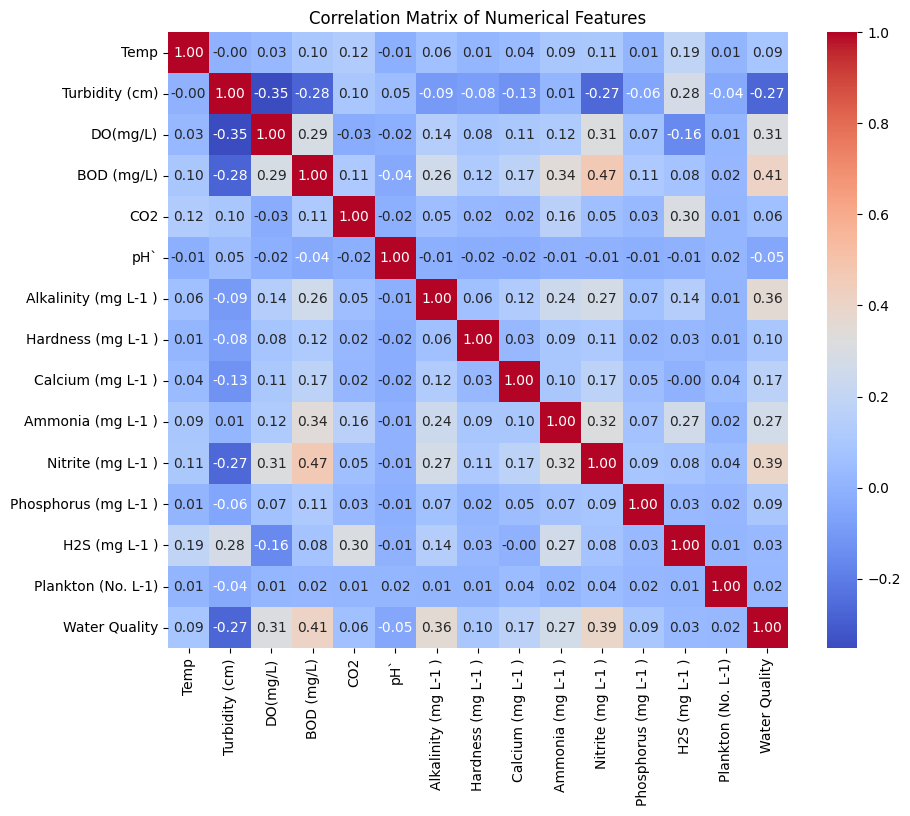

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=['number']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Analisis Data Eksploratif (EDA)**

**Distribution of Water Quality**

In [16]:
print("Distribution of 'Water Quality' column:")
print(data['Water Quality'].value_counts())

Distribution of 'Water Quality' column:
Water Quality
2    1500
1    1400
0    1400
Name: count, dtype: int64


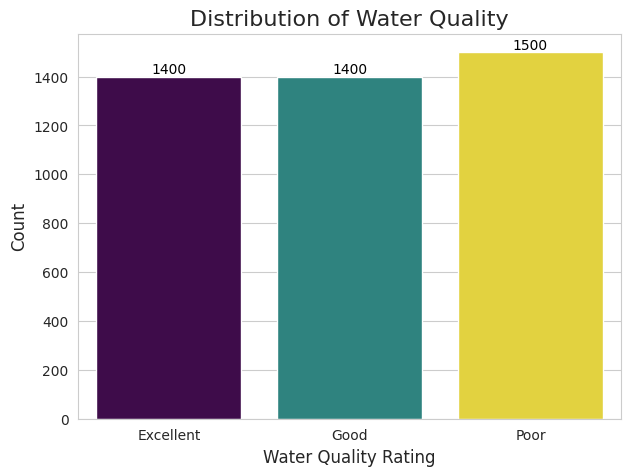

In [61]:
sns.set_style('whitegrid')
plt.figure(figsize=(7, 5))
sns.countplot(x='Water Quality', data=data, palette='viridis', hue='Water Quality', legend=False)

plt.title('Distribution of Water Quality', fontsize=16)
plt.xlabel('Water Quality Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)

custom_labels = {0: 'Excellent', 1: 'Good', 2: 'Poor'}
plt.xticks(ticks=sorted(custom_labels.keys()), labels=[custom_labels[key] for key in sorted(custom_labels.keys())], rotation=0)

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()

**Distribution of colom by Water Quality**

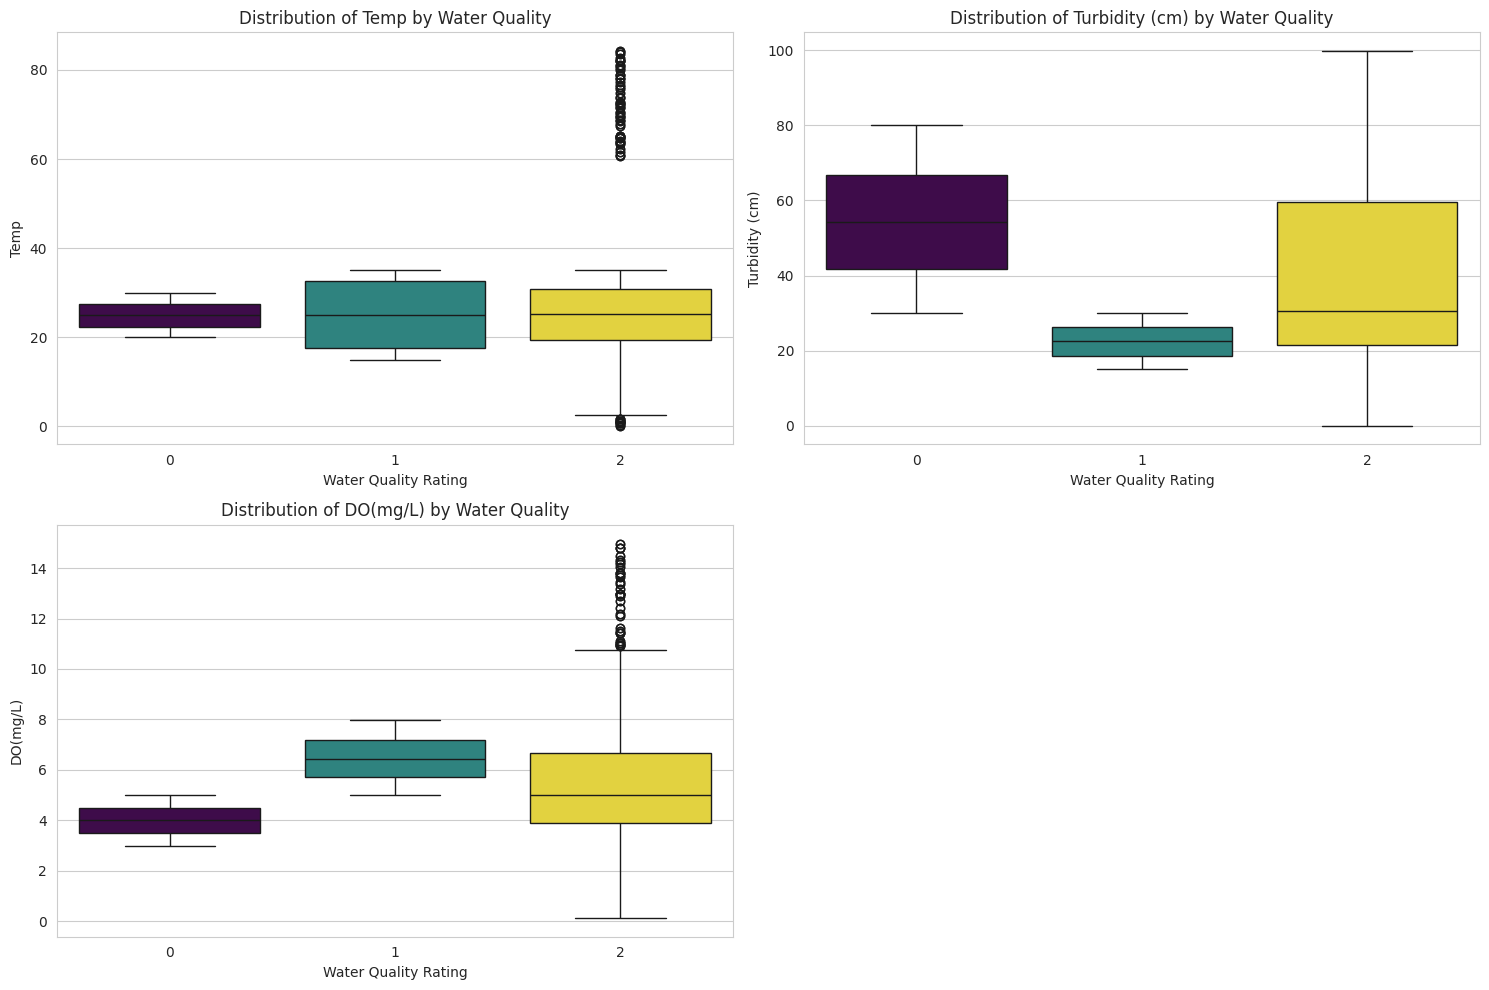

In [64]:
relevant_numerical_cols = ['Temp', 'Turbidity (cm)', 'DO(mg/L)']

n_cols = 2
n_rows = (len(relevant_numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(relevant_numerical_cols):
    sns.boxplot(
        x='Water Quality',
        y=col,
        data=data,
        ax=axes[i],
        palette='viridis',
        hue='Water Quality',
        legend=False
    )
    axes[i].set_title(f'Distribution of {col} by Water Quality')
    axes[i].set_xlabel('Water Quality Rating')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Visualisasi Distribusi Fitur**

Number of rows before dropping NaNs: 4300
Number of rows after dropping NaNs: 4300


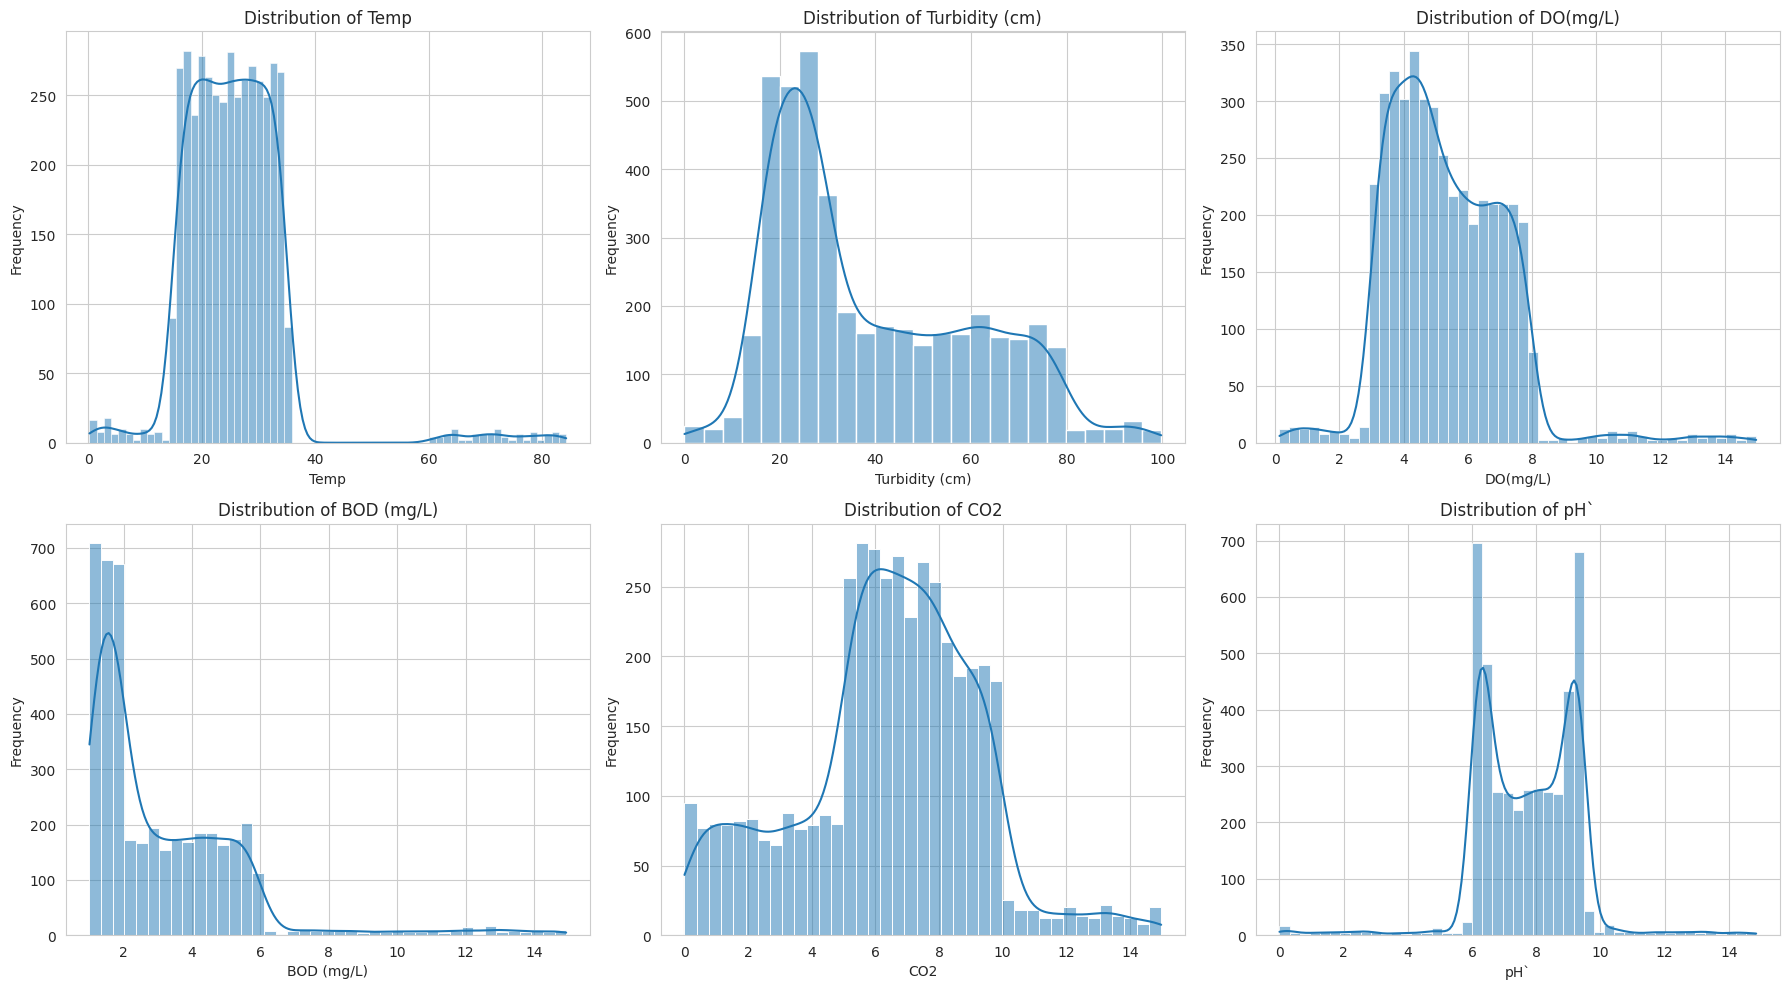

In [66]:
print(f"Number of rows before dropping NaNs: {len(data)}")
data.dropna(inplace=True)
print(f"Number of rows after dropping NaNs: {len(data)}")

numerical_cols_to_plot = [
    'Temp',
    'Turbidity (cm)',
    'DO(mg/L)',
    'BOD (mg/L)',
    'CO2',
    'pH`'
]

n_cols = 3
n_rows = (len(numerical_cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_to_plot):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [67]:
print('\nSkewness of numerical features after dropping NaNs:')
print(data[numerical_cols_to_plot].skew())


Skewness of numerical features after dropping NaNs:
Temp              2.534656
Turbidity (cm)    0.700381
DO(mg/L)          1.109894
BOD (mg/L)        2.205117
CO2              -0.157483
pH`              -0.380049
dtype: float64


In [68]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=5)
selector.fit(X, y)

top_features = X.columns[selector.get_support()].tolist()
print("Top 5 Selected Features:", top_features)

Top 5 Selected Features: ['Turbidity (cm)', 'Alkalinity (mg L-1 )', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )', 'Plankton (No. L-1)']


**Split Data**

In [69]:
X = data.drop(['Water Quality'], axis=1)
y = data['Water Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (3440, 14)
X_test shape: (860, 14)
y_train shape: (3440,)
y_test shape: (860,)


### Feature Scaling

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully!
X_train_scaled shape: (3440, 14)
X_test_scaled shape: (860, 14)


In [25]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_train_normalized = minmax_scaler.fit_transform(X_train_scaled)
X_test_normalized = minmax_scaler.transform(X_test_scaled)

print("Features normalized using MinMaxScaler successfully!")
print(f"X_train_normalized shape: {X_train_normalized.shape}")
print(f"X_test_normalized shape: {X_test_normalized.shape}")

Features normalized using MinMaxScaler successfully!
X_train_normalized shape: (3440, 14)
X_test_normalized shape: (860, 14)


**Cross-Validation**

In [70]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

cv_scores = cross_val_score(knn, X_train_normalized, y_train, cv=5, scoring='accuracy')

print("Cross-validation scores (accuracy) for each fold:")
print(cv_scores)
print(f"\nMean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of CV accuracy: {cv_scores.std():.4f}")

Cross-validation scores (accuracy) for each fold:
[0.8502907  0.87645349 0.86482558 0.8502907  0.87209302]

Mean CV accuracy: 0.8628
Standard deviation of CV accuracy: 0.0109


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import GaussianNB

pipeline = Pipeline([
    ('pt', PowerTransformer()),
    ('fs', SelectKBest(mutual_info_classif, k=20)),
    ('nb', GaussianNB())
])

pipeline.fit(X_train_normalized, y_train)
y_pred = pipeline.predict(X_test_normalized)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=14. All the features will be returned.
  warnings.warn(


In [71]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = GaussianNB()

nb_model.fit(X_train_normalized, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('fs', SelectKBest(mutual_info_classif)),
    ('nb', GaussianNB())
])

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("\nStarting GridSearchCV to find optimal parameters...")
grid_search.fit(X_train_normalized, y_train)


Starting GridSearchCV to find optimal parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('fs',
                                        SelectKBest(score_func=<function mutual_info_classif at 0x78e514367240>)),
                                       ('nb', GaussianNB())]),
             n_jobs=-1,
             param_grid={'fs__k': [5, 7, 10, 14],
                         'nb__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06,
                                               1e-05]},
             scoring='accuracy', verbose=1)

In [75]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Accuracy of the optimized Gaussian Naive Bayes model: {accuracy_optimized:.4f}")

print("\nClassification Report for Optimized Gaussian Naive Bayes Model:")
print(classification_report(y_test, y_pred_optimized))

Accuracy of the optimized Gaussian Naive Bayes model: 0.8907

Classification Report for Optimized Gaussian Naive Bayes Model:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       261
           1       0.81      1.00      0.90       274
           2       1.00      0.71      0.83       325

    accuracy                           0.89       860
   macro avg       0.90      0.90      0.89       860
weighted avg       0.91      0.89      0.89       860



In [76]:
gnb_comparison_df = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': y_pred_optimized
})

print("\nPerbandingan Nilai Aktual dan Prediksi (Optimized Gaussian Naive Bayes Model):")
display(gnb_comparison_df.head())


Perbandingan Nilai Aktual dan Prediksi (Optimized Gaussian Naive Bayes Model):


,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,2,2
4,2,1


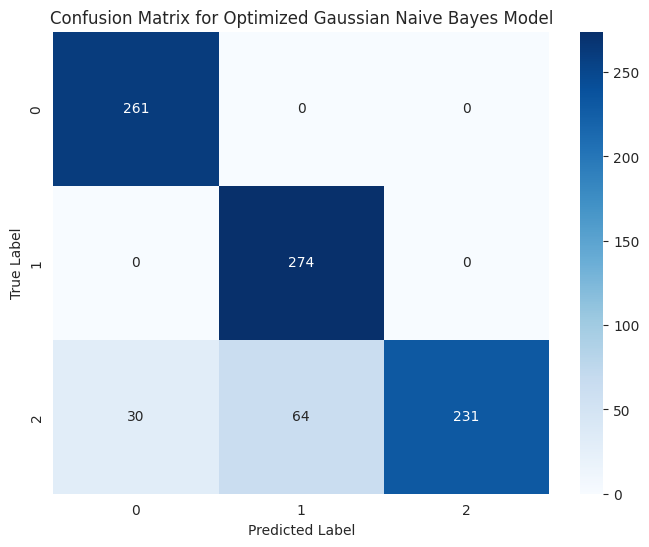

In [77]:
from sklearn.metrics import confusion_matrix

cm_gnb = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2]) # Assuming class labels are 0, 1, 2
plt.title('Confusion Matrix for Optimized Gaussian Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Feature Importances**

In [78]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_train, y_train)

feature_scores = pd.Series(selector.scores_, index=X_train.columns)

sorted_feature_scores = feature_scores.sort_values(ascending=False)

print("Ranking Fitur (Chi-Square):")
print(sorted_feature_scores)


Ranking Fitur (Chi-Square):
Alkalinity (mg L-1 )    22811.228828
Turbidity (cm)          14783.055373
Calcium (mg L-1 )       10514.570899
Plankton (No. L-1)       4444.717167
Hardness (mg L-1 )       3029.978069
BOD (mg/L)               1437.867840
Nitrite (mg L-1 )        1060.736854
DO(mg/L)                  653.467901
Temp                      132.662779
CO2                       106.297664
Ammonia (mg L-1 )          80.717335
Phosphorus (mg L-1 )       40.749190
H2S (mg L-1 )               4.992029
pH`                         1.742450
dtype: float64


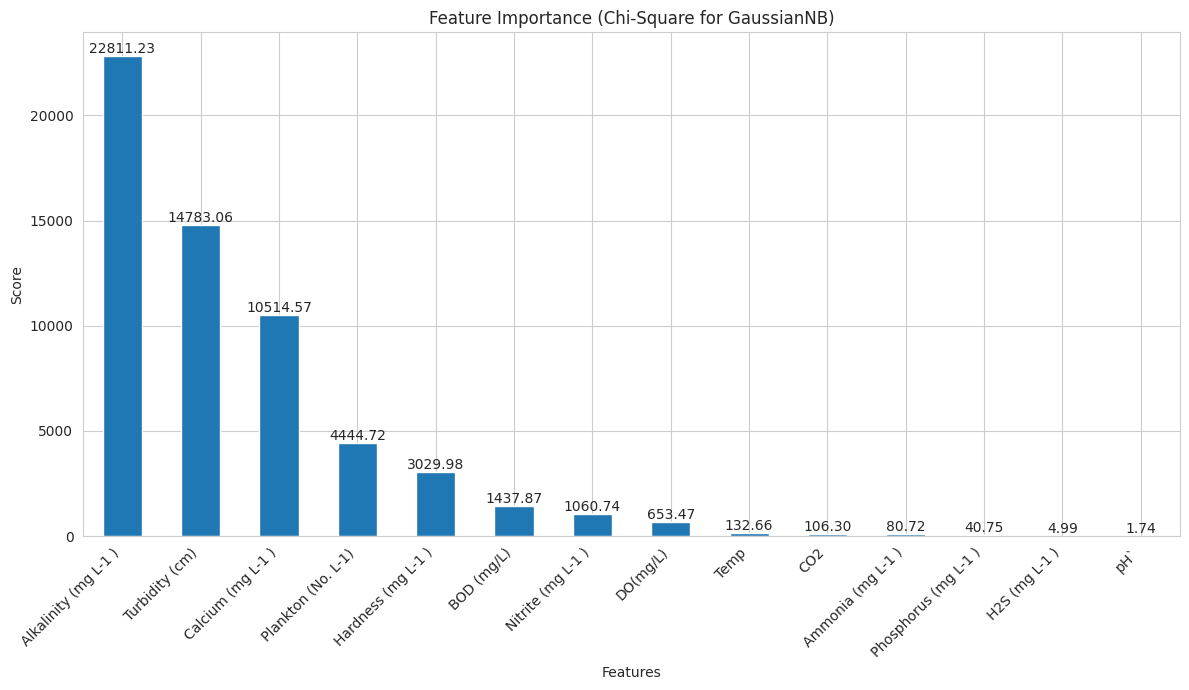

In [79]:
plt.figure(figsize=(12, 7))
ax = sorted_feature_scores.plot(kind='bar')
plt.title('Feature Importance (Chi-Square for GaussianNB)')
plt.xlabel('Features')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()